
# `pybayescointur` — a hands-on tutorial

### Bayesian unit-root &amp; cointegration tests for panel data

**Author:** Dr Merwan Roudane &nbsp;·&nbsp;
✉️ [merwanroudane920@gmail.com](mailto:merwanroudane920@gmail.com) &nbsp;·&nbsp;
📦 [PyPI](https://pypi.org/project/pybayescointur/) &nbsp;·&nbsp;
🐙 [GitHub](https://github.com/merwanroudane/pybayescointur)

---

This notebook walks through the **four** Bayesian panel methods implemented in
`pybayescointur`, with a little theory, realistic data, clean tables and
light-themed visualisations.

| # | Method | Function |
|---|--------|----------|
| 1 | Panel unit root via Posterior Odds Ratio | `bayesian_panel_unit_root` |
| 2 | Unit root with structural break (mean &amp; variance) | `bayesian_break_unit_root` |
| 3 | Model comparison under cross-sectional dependence | `bayesian_csd_comparison` |
| 4 | Panel cointegration (VECM, rank inference) | `bayesian_panel_cointegration` |



## A little theory

Classical unit-root and cointegration tests rely on asymptotic distributions
and a sharp null hypothesis. The **Bayesian** approach instead compares models
through their *marginal likelihoods* and reports directly interpretable
probabilities and odds.

**Posterior odds ratio.** For a null $H_0$ against an alternative $H_1$,

$$
\beta_{01}=\underbrace{\frac{P(H_0)}{P(H_1)}}_{\text{prior odds}}\times
\underbrace{\frac{P(y\mid H_0)}{P(y\mid H_1)}}_{\text{Bayes factor}}
=\frac{P(H_0\mid y)}{P(H_1\mid y)} .
$$

The **Bayes factor** integrates each model's parameters out of the likelihood,

$$
P(y\mid H_k)=\int P(y\mid\theta_k,H_k)\,p(\theta_k\mid H_k)\,d\theta_k ,
$$

so it automatically penalises complexity (an Occam factor) — no degrees-of-freedom
corrections needed.

**Decision rule.** $\beta_{01}<1$ is evidence *against* the null (e.g. reject a
unit root → trend stationary); $\beta_{01}>1$ favours the null.

**Why panels?** Pooling the cross-section ($n$ units) with the time dimension
($T$) sharply increases the power to distinguish a unit root from a stationary
root close to one — the central motivation of the panel literature.

Numerically, these marginal likelihoods involve quantities such as
$\eta(\rho)^{\,nT/2}$ that overflow instantly, so `pybayescointur` integrates
everything in **log-space** (`utils.log_trapz`).


In [1]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pybayescointur as pbc

# clean LIGHT theme for every figure
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#d0d7de", "axes.grid": True,
    "grid.color": "#e7ebf0", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "legend.frameon": False,
    "figure.dpi": 110, "font.size": 11,
})
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print("pybayescointur", pbc.__version__)


pybayescointur 0.1.0



## 1 · Panel unit root via the Posterior Odds Ratio
*Kumar, Chaturvedi &amp; Afifa (2016)*

Model: $y_{it}=\mu_i+\delta_i t+u_{it}$, $u_{it}=\rho\,u_{i,t-1}+\varepsilon_{it}$.
Test $H_0:\rho=1$ (difference stationary) vs $H_1:a<\rho<1$ (trend stationary).
We integrate $\rho$ out of the posterior; `model="augmented"` adds $k$
lagged-difference terms per unit (more reliable when $\hat\rho$ is near one).


In [2]:

panel = pbc.simulate_par_panel(n=4, T=72, rho=0.94, delta=[0.04]*4, seed=11)
panel.columns = ["ICICI", "KM", "SBI", "UTI"]

res1 = pbc.bayesian_panel_unit_root(panel, model="augmented", k=2)
print(res1)
res1.to_frame()


Bayesian Panel Unit-Root Test  (Posterior Odds Ratio)
Kumar, Chaturvedi & Afifa (2016)
--------------------------------------------------------
  model                 : trend + aug(order 2)
  cross-section units n : 4
  time periods T        : 71
  augmentation k        : 2
  prior P(H0)=p0        : 0.500
  vartheta              : 1
  lower bound a         : 0.0000
--------------------------------------------------------
  rho_hat (MLE)         : 0.9136
  se(rho_hat)           : 0.0252
  sigma^2               : 0.8548
  POR  beta_01          : 0.125353
  log POR               : -2.0766
--------------------------------------------------------
  Decision: Reject H0 (unit root) -> series is TREND STATIONARY


,model,n_units,T,rho_hat,se(rho),sigma2,POR (beta_01),decision
0,trend + aug(order 2),4,71,0.9136,0.02525,0.8548,0.1254,Reject H0 (unit root) -> series is TREND STATI...


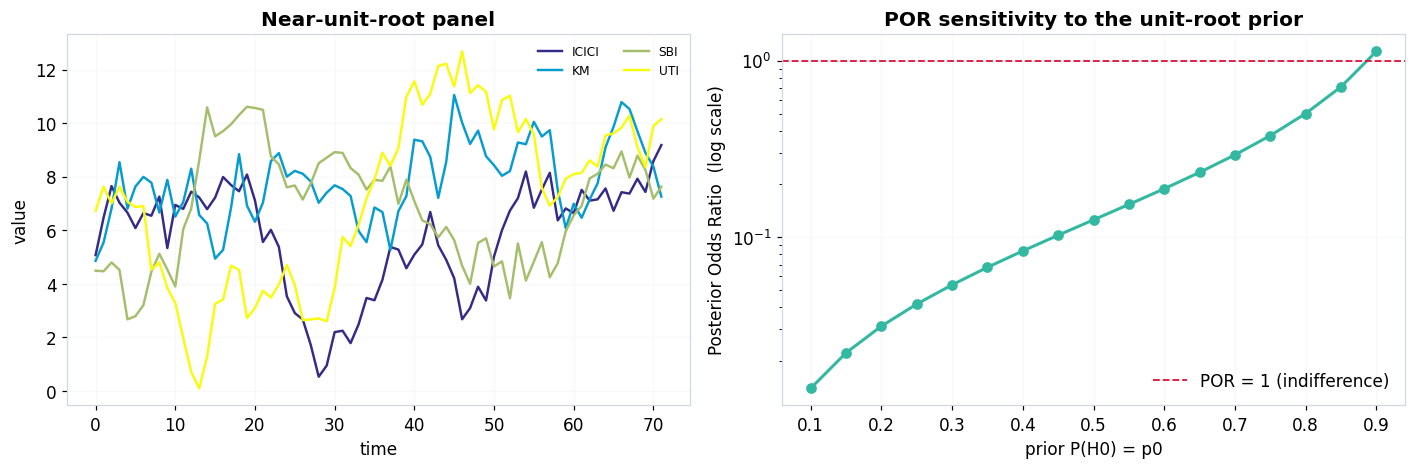

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
pbc.plot_panel(panel, title="Near-unit-root panel", ax=axes[0])
pbc.plot_por_sensitivity(panel, model="augmented", k=2, ax=axes[1])
plt.tight_layout(); plt.show()



## 2 · Unit root with a structural break in mean &amp; variance
*Kumar &amp; Agiwal (2019)*

A PAR(1) panel with a single common break at $T_B$ that may shift both the mean
($\mu_{i1}\neq\mu_{i2}$) and the error variance ($\lambda\neq1$). Eight nested
hypotheses give **14 posterior odds ratios**; $\beta<1$ favours the numerator.


In [4]:

brk = pbc.simulate_break_panel(n=3, T=34, TB=20, rho=0.93, lam=4.0,
                               mu1=(40,55,70), mu2=(120,150,180), seed=5)
brk.columns = ["N", "P", "K"]
res2 = pbc.bayesian_break_unit_root(brk, TB=20)
res2.to_frame()


,POR,comparison,value,decision
0,beta_01,"DS, break in var vs TS, break in mean & var",74.17,accept null
1,beta_02,"TS, break in var vs TS, break in mean & var",0.8993,reject null
2,beta_03,"TS, break in mean vs TS, break in mean & var",2.426e-19,reject null
3,beta_04,"DS, no break vs TS, break in mean & var",9.381e-19,reject null
4,beta_05,"TS, no break vs TS, break in mean & var",3.574e-20,reject null
5,beta_06,"DS, break in var vs TS, break in var",82.48,accept null
6,beta_07,"TS, break in mean vs TS, break in var",2.698e-19,reject null
7,beta_08,"DS, no break vs TS, break in var",1.043e-18,reject null
8,beta_09,"TS, no break vs TS, break in var",3.974e-20,reject null
9,beta_10,"DS, no break vs TS, break in mean",3.867,accept null


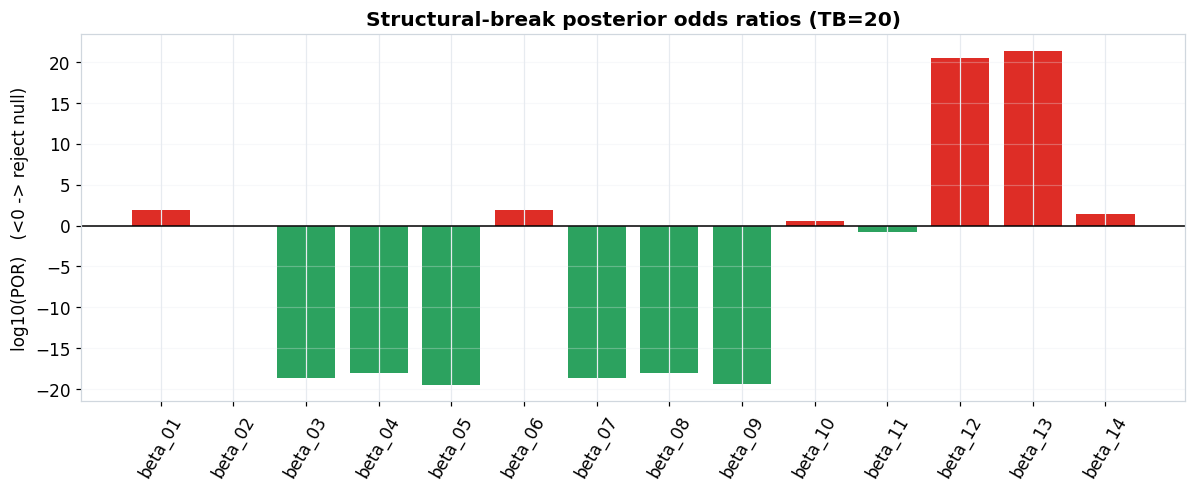

In [5]:

fig, ax = plt.subplots(figsize=(11, 4.6))
pbc.plot_break_por(res2, ax=ax); plt.tight_layout(); plt.show()



## 3 · Model comparison under cross-sectional dependence
*Meligkotsidou, Tzavalis &amp; Vrontos*

Eight models — {stationary, random walk} × {trend, no trend} ×
{independent, cross-sectionally dependent} — are ranked by posterior
probability. Ignoring cross-sectional dependence can badly distort unit-root
inference, so the dependent models usually win for macro panels.


In [6]:

gdp = pbc.load_g7_like_gdp()
res3 = pbc.bayesian_csd_comparison(gdp)
print("Most probable model:", res3.best_model)
res3.to_frame()


Most probable model: m2


,model,description,log_ML,post_prob
1,m2,"stationary, no trend, cross-dependence",684.6,1
3,m4,"stationary, trend, cross-dependence",659.9,2.022e-11
5,m6,"pure random walk, cross-dependence",589.9,7.48e-42
7,m8,"random walk + drift, cross-dependence",566.5,5.335e-52
2,m3,"stationary, trend, independent",376.1,1.089e-134
0,m1,"stationary, no trend, independent",358,1.487e-142
4,m5,"pure random walk, independent",-47.49,1.185e-318
6,m7,"random walk + drift, independent",-70.02,0


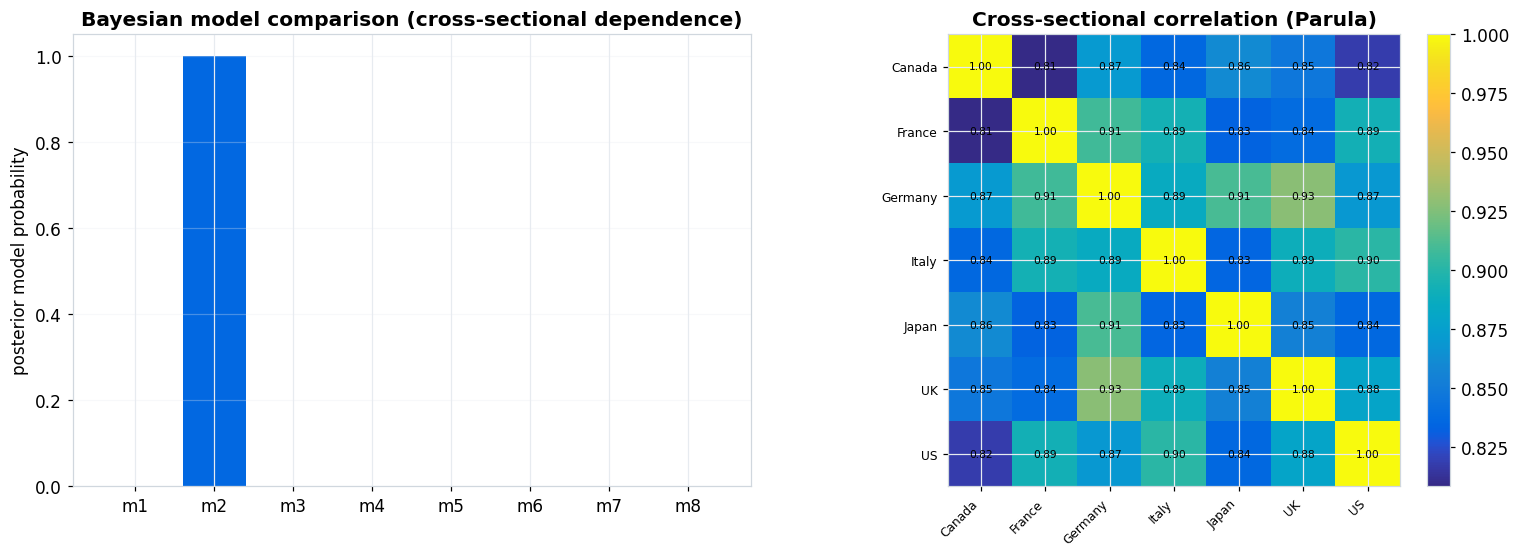

,Canada,France,Germany,Italy,Japan,UK,US
Canada,1,0.81,0.87,0.84,0.86,0.85,0.82
France,0.81,1,0.91,0.89,0.83,0.84,0.89
Germany,0.87,0.91,1,0.89,0.91,0.93,0.87
Italy,0.84,0.89,0.89,1,0.83,0.89,0.9
Japan,0.86,0.83,0.91,0.83,1,0.85,0.84
UK,0.85,0.84,0.93,0.89,0.85,1,0.88
US,0.82,0.89,0.87,0.9,0.84,0.88,1


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
pbc.plot_csd_probabilities(res3, ax=axes[0])
pbc.plot_correlation_heatmap(res3, ax=axes[1])
plt.tight_layout(); plt.show()
res3.correlation_frame().round(2)



## 4 · Bayesian panel cointegration
*Koop, Leon-Gonzalez &amp; Strachan (2006)*

Each unit has its own VECM
$\;\Delta y_{i,t}=\alpha_i\beta_i'y_{i,t-1}+\dots+\varepsilon_{i,t}\;$
with possibly **unit-specific cointegrating rank** $r_i$. Ranks are inferred via
**Savage–Dickey** Bayes factors against the no-cointegration model ($\alpha_i=0$).


In [8]:

panels = pbc.simulate_vecm_panel(N=3, n=2, T=140, ranks=[1,0,1], seed=3)
res4 = pbc.bayesian_panel_cointegration(panels, lags=1, deterministic="c",
                                        draws=1500, burn=300,
                                        names=["France","Germany","UK"], seed=7)
print(res4)
res4.rank_frame()


Bayesian Panel Cointegration  (Koop, Leon-Gonzalez & Strachan)
------------------------------------------------------------
  [France] MAP rank=1 | r=0:0.000  r=1:1.000  r=2:0.000
  [Germany] MAP rank=0 | r=0:1.000  r=1:0.000  r=2:0.000
  [UK] MAP rank=1 | r=0:0.002  r=1:0.995  r=2:0.003
------------------------------------------------------------
  Common-rank posterior:  r=0:0.000  r=1:1.000  r=2:0.000
  MAP common rank: 1


,unit,MAP_rank,P(r=0),P(r=1),P(r=2)
0,France,1,1.708e-11,0.9998,0.0001587
1,Germany,0,0.9999,6.415e-05,1.512e-08
2,UK,1,0.00169,0.9949,0.00337


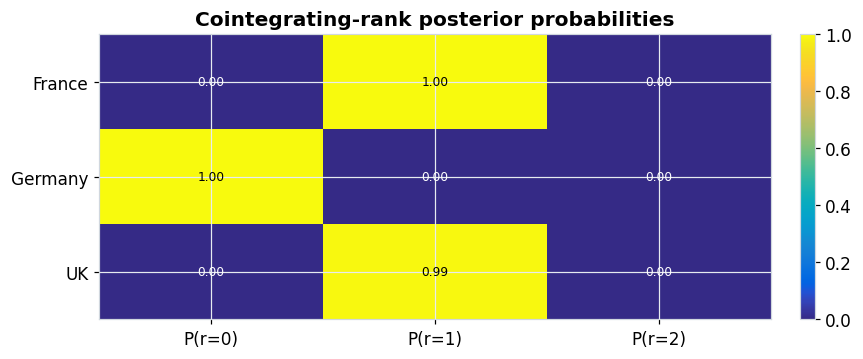

Recovered cointegrating vector of unit 1 (~ (1, -1)/sqrt(2)):
[[ 0.702]
 [-0.713]]


In [9]:

fig, ax = plt.subplots(figsize=(8, 3.4))
pbc.plot_rank_posterior(res4, ax=ax); plt.tight_layout(); plt.show()

print("Recovered cointegrating vector of unit 1 (~ (1, -1)/sqrt(2)):")
print(np.round(res4.units[0].beta, 3))



## Colour palette

Every heatmap defaults to the MATLAB **Parula** colormap, reproduced from its
64 RGB control points. Helpers: `parula_colors`, `matlab_jet_colors`,
`turbo_colors`, and `resolve_colorscale` (for plotly).


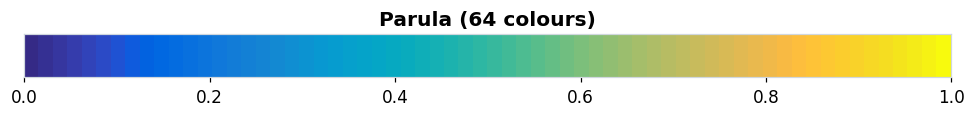

['#352a87', '#0f77db', '#07aac1', '#7abf7c', '#ecb94c', '#f9fb0e']

In [10]:

cols = pbc.parula_colors(64, as_hex=False)
fig, ax = plt.subplots(figsize=(9, 1.2))
ax.imshow([cols], aspect="auto", extent=[0,1,0,1]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Parula (64 colours)"); plt.tight_layout(); plt.show()
pbc.parula_colors(6)



## References

1. Kumar, Chaturvedi &amp; Afifa (2016). *Bayesian Unit Root Test for Panel Data.* EERI RP 14/2016.
2. Kumar &amp; Agiwal (2019). *Panel data unit root test with structural break: A Bayesian approach.* Hacettepe J. Math. Stat. 48(4). doi:10.15672/HJMS.2018.626
3. Meligkotsidou, Tzavalis &amp; Vrontos. *A Bayesian Analysis of Unit Roots in Panel Data Models with Cross-sectional Dependence.*
4. Koop, Leon-Gonzalez &amp; Strachan (2006). *Bayesian Inference in a Cointegrating Panel Data Model.*

---
*© 2026 Dr Merwan Roudane — MIT License — built with*
[`pybayescointur`](https://github.com/merwanroudane/pybayescointur).
